# Evaluation Notebook — Speech Deepfake Detection

Loads the **trained** model weights, runs predictions on an evaluation dataset, and
produces the metrics and plots used in the README **Results** section.

Everything is imported from the repo's own modules (`pm.model`, `pm.dataset.dataloader`,
`pm.train_model`) — no model, dataset, or metric code is redefined here.

By default this runs on the four bundled example clips so it always executes after a
fresh `pip install .`. The numbers/figures shown below are therefore a **pipeline
sanity-check on 4 toy clips**, not the reported test results. To reproduce the full
ASVspoof numbers, point `DATA_DIR` / `METADATA` at the extracted eval set on Talapas
and `WEIGHTS` at the trained weights (see the README and `pm/dataset/data.md`).

## Config

In [1]:
import os, sys
from pathlib import Path

# make the repo importable when running from notebooks/
repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.chdir(repo_root)

# Trained weights produced by `python -m pm.train_model ...`.
WEIGHTS  = "pm/model/weights/model.pt"

# Dataset to evaluate on. Default = bundled example so this notebook always runs.
# For the real results, set these to the extracted held-out eval set on Talapas, e.g.:
#   DATA_DIR = "pm/dataset/ASVspoof2021_LA_eval/flac"
#   METADATA = "pm/dataset/ASVspoof2021_LA_eval/trial_metadata.txt"
#   AUDIO_EXT = ".flac"
DATA_DIR  = "assets/example_audio"
METADATA  = "assets/trial_metadata.txt"
AUDIO_EXT = ".wav"

BATCH_SIZE = 32
FIG_DIR    = "assets/eval_figures"      # plots for the README land here
os.makedirs(FIG_DIR, exist_ok=True)

## Load dataset + trained model (from the repo's modules)

In [2]:
import torch
from torch.utils.data import DataLoader
from pm.model import AudioClassifier
from pm.dataset.dataloader import ASVspoofAudioDataset, LABEL_TO_ID

ID2LABEL = {v: k for k, v in LABEL_TO_ID.items()}   # {0:'spoof', 1:'bonafide'}

ds = ASVspoofAudioDataset(protocol_path=METADATA, audio_dir=DATA_DIR, audio_ext=AUDIO_EXT)
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AudioClassifier(num_classes=len(LABEL_TO_ID)).to(device)
model.load_state_dict(torch.load(WEIGHTS, map_location=device))
model.eval()
print(f"loaded {WEIGHTS} | {len(ds)} examples | device {device}")

loaded pm/model/weights/model.pt | 4 examples | device cpu


## Predict

In [3]:
import numpy as np
y_true, y_pred, y_score, specs = [], [], [], []
with torch.no_grad():
    for x, y in loader:
        logits = model(x.to(device))
        prob_spoof = torch.softmax(logits, dim=1)[:, LABEL_TO_ID["spoof"]].cpu()  # P(spoof)
        y_pred  += logits.argmax(1).cpu().tolist()
        y_score += prob_spoof.tolist()
        y_true  += [int(v) for v in y]
        specs   += [xi.squeeze(0).numpy() for xi in x.cpu()]
print("predicted", len(y_pred), "examples")

predicted 4 examples


## Metrics — EER, accuracy, precision, recall, F1
*Spoof (label id 0) is the positive class — the goal is detecting the fake.*
EER (Equal Error Rate) is the primary ASVspoof metric; the `compute_eer` helper is
imported from `pm.train_model` so training and evaluation use the exact same definition.

In [4]:
from pm.train_model import compute_eer

tp = sum(t==0 and p==0 for t,p in zip(y_true,y_pred))   # spoof correctly caught
tn = sum(t==1 and p==1 for t,p in zip(y_true,y_pred))   # bonafide correctly passed
fp = sum(t==1 and p==0 for t,p in zip(y_true,y_pred))   # bonafide flagged as spoof
fn = sum(t==0 and p==1 for t,p in zip(y_true,y_pred))   # spoof missed

precision = tp/(tp+fp) if tp+fp else 0.0
recall    = tp/(tp+fn) if tp+fn else 0.0
accuracy  = (tp+tn)/max(len(y_true),1)
f1        = 2*precision*recall/(precision+recall) if precision+recall else 0.0

spoof_indicator = [1 if t==LABEL_TO_ID["spoof"] else 0 for t in y_true]
eer, eer_thr = compute_eer(y_score, spoof_indicator)

print(f"EER       {eer:.3f}  (threshold {eer_thr:.3f})")
print(f"accuracy  {accuracy:.3f}")
print(f"precision {precision:.3f}")
print(f"recall    {recall:.3f}")
print(f"f1        {f1:.3f}")
print(f"confusion  TP={tp} TN={tn} FP={fp} FN={fn}")

import json
with open(os.path.join(FIG_DIR, "metrics.json"), "w") as f:
    json.dump({"eer":eer,"accuracy":accuracy,"precision":precision,"recall":recall,
               "f1":f1,"confusion":{"tp":tp,"tn":tn,"fp":fp,"fn":fn},
               "n":len(y_true)}, f, indent=2)

EER       1.000  (threshold 0.604)
accuracy  0.500
precision 0.500
recall    1.000
f1        0.667
confusion  TP=2 TN=0 FP=2 FN=0


## Visualization 1 — confusion matrix

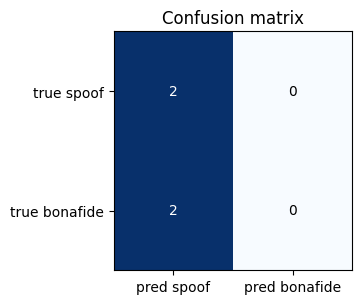

In [5]:
import matplotlib.pyplot as plt
cm = np.array([[tp, fn], [fp, tn]])
fig, ax = plt.subplots(figsize=(3.6, 3.3))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_xticklabels(["pred spoof","pred bonafide"])
ax.set_yticks([0,1]); ax.set_yticklabels(["true spoof","true bonafide"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_title("Confusion matrix")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,"confusion.png"), dpi=150); plt.show()

## Visualization 2 — model predictions on example spectrograms
Each panel is one clip's log-spectrogram with its true vs. predicted label. This is the
prediction visualization embedded in the README Results section.

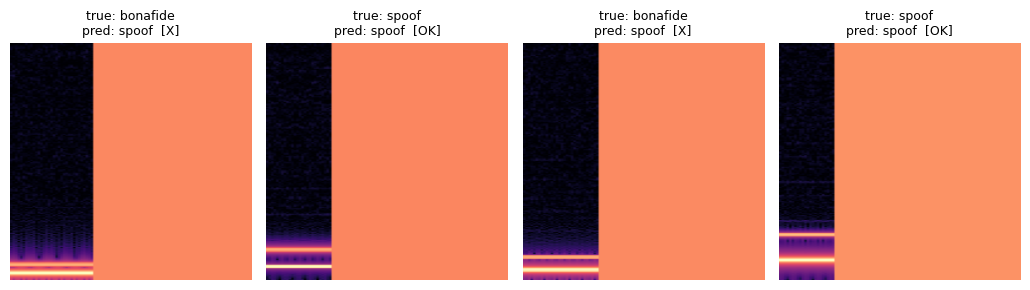

In [6]:
k = min(8, len(specs))
fig, axes = plt.subplots(1, k, figsize=(2.6*k, 3))
axes = np.atleast_1d(axes)
for i, ax in enumerate(axes):
    ax.imshow(specs[i].T, aspect="auto", origin="lower", cmap="magma")
    ok = "OK" if y_true[i]==y_pred[i] else "X"
    ax.set_title(f"true: {ID2LABEL[y_true[i]]}\npred: {ID2LABEL[y_pred[i]]}  [{ok}]", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,"predictions.png"), dpi=150); plt.show()

## Done
`assets/eval_figures/` now holds `confusion.png`, `predictions.png`, and `metrics.json`
— those are embedded in the README Results section. Re-run with `DATA_DIR` / `METADATA` /
`WEIGHTS` pointed at the full extracted eval set on Talapas to generate the numbers you
actually report.